## The k-NN classifier

### 1. k-NN classifier using a toy dataset

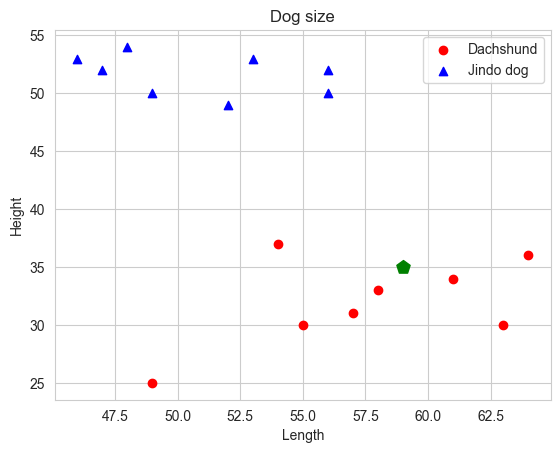

In [1]:
# 그래프를 그리기 위해 matplotlib의 pyplot 모듈을 불러온다.
import matplotlib.pyplot as plt

# 닥스훈트의 몸길이(cm)와 몸높이(cm) 관측값을 리스트로 저장한다.
dach_length = [55, 57, 64, 63, 58, 49, 54, 61]
dach_height = [30, 31, 36, 30, 33, 25, 37, 34]

# 진돗개의 몸길이(cm)와 몸높이(cm) 관측값을 리스트로 저장한다.
jin_length = [56, 47, 56, 46, 49, 53, 52, 48]
jin_height = [52, 52, 50, 53, 50, 53, 49, 54]

# 분류하려는 새 강아지 데이터의 몸길이와 몸높이를 별도 리스트로 저장한다.
newdata_length = [59]
newdata_height = [35]

# 닥스훈트 데이터를 빨간 원으로 산점도에 표시한다.
plt.scatter(dach_length, dach_height, c='r', label='Dachshund')

# 진돗개 데이터를 파란 삼각형으로 산점도에 표시한다.
plt.scatter(jin_length, jin_height, c='b', marker='^', label='Jindo dog')

# x축, y축, 제목, 범례를 설정해 그래프의 의미를 표시한다.
plt.xlabel('Length')
plt.ylabel('Height')
plt.title("Dog size")
plt.legend(loc='upper right')

# 새 데이터를 초록색 오각형 마커로 표시한다.
plt.scatter(newdata_length, newdata_height, s=100, marker='p',
            c='g', label='new Data')

### Stack the data together

In [7]:
# 배열 연산을 위해 NumPy를 불러온다.
import numpy as np

# 닥스훈트의 길이와 높이를 한 행에 묶어 2차원 특징 데이터로 만든다.
d_data = np.column_stack((dach_length, dach_height))

# 닥스훈트 클래스 라벨은 0으로 지정한다.
d_label = np.zeros(len(d_data))

# 진돗개의 길이와 높이를 한 행에 묶어 2차원 특징 데이터로 만든다.
j_data = np.column_stack((jin_length, jin_height))

# 진돗개 클래스 라벨은 1로 지정한다.
j_label = np.ones(len(j_data))

# 두 품종의 특징 데이터를 하나의 학습 데이터 배열로 합친다.
dogs = np.concatenate((d_data, j_data))

# 두 품종의 라벨 데이터를 하나의 정답 라벨 배열로 합친다.
labels = np.concatenate((d_label, j_label))

# 숫자 라벨을 사람이 읽기 쉬운 품종 이름으로 바꾸기 위한 딕셔너리이다.
dog_classes = {0:'닥스훈트', 1:'진돗개'}

# 학습에 사용할 특징 데이터와 라벨 데이터를 확인한다.
print('dogs:', dogs)
print(np.shape(dogs))
print('labels:', labels)

dogs: [[55 30]
 [57 31]
 [64 36]
 [63 30]
 [58 33]
 [49 25]
 [54 37]
 [61 34]
 [56 52]
 [47 52]
 [56 50]
 [46 53]
 [49 50]
 [53 53]
 [52 49]
 [48 54]]
(16, 2)
labels: [0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1.]


### Classify using the k-NN classifier

In [5]:
# scikit-learn의 k-최근접 이웃 분류기를 불러온다.
from sklearn.neighbors import KNeighborsClassifier

# 분류할 새 강아지 데이터를 [몸길이, 몸높이] 형태로 준비한다.
newdata = [[59, 35]]

# 가까운 이웃 3개를 기준으로 분류하도록 k 값을 설정한다.
k = 3

# k-NN 분류기 객체를 생성한다.
knn = KNeighborsClassifier(n_neighbors=k)

# 강아지 특징 데이터와 라벨을 이용해 분류기를 학습시킨다.
knn.fit(dogs, labels)

# 학습된 분류기로 새 데이터의 품종 라벨을 예측한다.
y_pred = knn.predict(newdata)

# 예측된 숫자 라벨을 품종 이름으로 바꿔 출력한다.
print('data', newdata, ', classified as:', dog_classes[y_pred[0]])

data [[59, 35]] , classified as: 닥스훈트


### Visualize the nearest neighbors

dist = [[2.23606798 2.23606798 4.47213595]] indexes = [[4 7 1]] dogs[indexes]= [[[58 33]
  [61 34]
  [57 31]]]
data [[59, 35]] , classified as: 닥스훈트


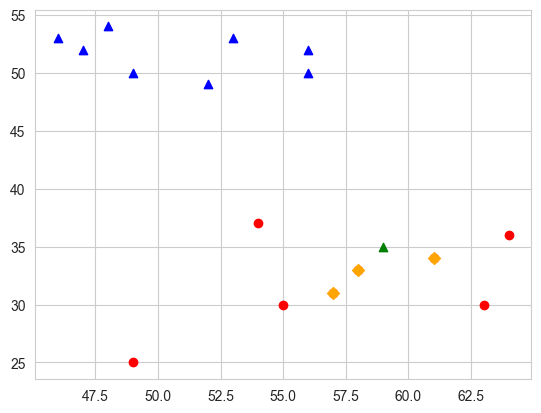

In [6]:
# 새 데이터와 가장 가까운 k개 이웃의 거리와 인덱스를 구한다.
distances, indexes = knn.kneighbors(newdata)

# 계산된 거리, 이웃 인덱스, 실제 이웃 데이터를 출력해 확인한다.
print('dist =', distances, 'indexes =', indexes, 'dogs[indexes]=', dogs[indexes])

# 가장 가까운 이웃들을 산점도 위에 주황색 다이아몬드로 표시하는 함수이다.
def draw_neighbor(data, index, k):
    # k개의 이웃을 하나씩 순회하며 해당 좌표를 강조 표시한다.
    for i in range(k):
        plt.scatter(data[index][0][i][0], dogs[index][0][i][1], marker='D', color='orange')

# 새 데이터를 초록색 삼각형으로 표시한다.
plt.scatter(59, 35, color='green', marker='^')

# 기존 닥스훈트와 진돗개 데이터를 다시 산점도에 표시한다.
plt.scatter(dach_length, dach_height, c='red', label='Dachshund')
plt.scatter(jin_length, jin_height, c='blue', marker='^', label='Jindo dog')

# 새 데이터 기준으로 선택된 최근접 이웃들을 그래프에 표시한다.
draw_neighbor(dogs, indexes, k)

# 새 데이터의 최종 분류 결과를 출력한다.
print('data', newdata, ', classified as:', dog_classes[y_pred[0]])

### Classifying iris using k-NN Classifier

In [16]:
# scikit-learn에서 제공하는 붓꽃 데이터셋 로더를 불러온다.
from sklearn.datasets import load_iris

# 붓꽃 데이터셋을 메모리에 로드한다.
iris = load_iris()

# 전체 데이터 중 앞의 세 행을 확인한다.
iris.data[:3]

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2]])

In [9]:
# 붓꽃 특징 데이터의 행과 열 개수를 출력한다.
print('iris data shape:', iris.data.shape)

iris data shape: (150, 4)


In [10]:
# 각 특징 열이 어떤 측정값을 의미하는지 출력한다.
print('iris data features:', iris.feature_names)

iris data features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [13]:
# 각 샘플의 품종 라벨을 출력한다.
print('iris data labels:', iris.target)

iris data labels: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


### Not necessary, but let's transform the data in to a Pandas DataFrame

In [18]:
# 표 형태의 데이터 처리를 위해 pandas를 불러온다.
import pandas as pd

# 붓꽃 특징 데이터를 컬럼 이름이 있는 DataFrame으로 변환한다.
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)

# 정답 라벨을 target 컬럼으로 추가한다.
iris_df['target'] = pd.Series(iris.target)

# DataFrame의 앞부분을 확인한다.
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [19]:
# 각 특징과 라벨 컬럼의 기초 통계량을 확인한다.
iris_df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [20]:
# DataFrame의 첫 5개 행을 다시 확인한다.
iris_df.head(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [29]:
# 앞의 4개 컬럼을 입력 특징 X로 선택한다.
print(np.shape(iris_df))
X = iris_df.iloc[:, :4]

# 마지막 target 컬럼을 정답 라벨 y로 선택한다.
y = iris_df.iloc[:, -1]

(150, 5)


In [33]:
# 학습/테스트 데이터 분할 함수를 불러온다.
from sklearn.model_selection import train_test_split

# k-NN 분류기와 평가 지표 모듈을 불러온다.
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics

# 주어진 X, y와 k 값으로 k-NN 모델을 학습하고 정확도를 반환하는 함수이다.
def iris_knn(X, y, k):
    # 전체 데이터를 학습용 70%, 테스트용 30%로 나눈다.
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=11)

    # 지정된 k 값을 사용하는 k-NN 분류기를 생성한다.
    knn = KNeighborsClassifier(n_neighbors=k)

    # 학습 데이터로 모델을 학습시킨다.
    knn.fit(X_train, y_train)

    # 테스트 데이터의 라벨을 예측한다. 실제 내부에서는 (x_test, y_test) 와 (x_train, y_train) 의 distance 를 구한뒤 정렬을 한다음, k 개만큼 구하고, k개의 데이터로 평균을 낸다.
    y_pred = knn.predict(X_test)

    # 실제 테스트 라벨과 예측 라벨을 비교해 정확도를 계산한다.
    return metrics.accuracy_score(y_test, y_pred)

# k 값을 3으로 두고 모델 성능을 확인한다.
k = 3
scores = iris_knn(X, y, k)

# k=3일 때의 정확도를 소수 셋째 자리까지 출력한다.
print('n_neighbors가 {0:d}일때 정확도: {1:.3f}'.format(k, scores))

n_neighbors가 3일때 정확도: 0.956


### Observe the accuracy for different k-values

In [34]:
# 여러 k 값에 대해 같은 데이터 분할과 평가 절차를 반복한다.
for i in [1, 5, 10, 20, 30]:
    # 현재 k 값으로 k-NN 모델의 정확도를 계산한다.
    scores = iris_knn(X, y, i)

    # 현재 k 값과 정확도를 출력해 성능 변화를 비교한다.
    print('n_neighbors가 {0:d}일때 정확도: {1:.3f}'.format(i, scores))

n_neighbors가 1일때 정확도: 0.933
n_neighbors가 5일때 정확도: 0.978
n_neighbors가 10일때 정확도: 0.956
n_neighbors가 20일때 정확도: 0.933
n_neighbors가 30일때 정확도: 0.911


### Apply the model to a new data for classification



In [37]:
# 붓꽃 데이터셋과 k-NN 분류기를 다시 불러온다.
from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier

# 전체 붓꽃 데이터에 사용할 이웃 수를 3으로 설정한다.
k = 3

# 붓꽃 데이터셋을 로드한다.
iris = load_iris()

# k=3인 k-NN 분류기를 생성한다.
knn = KNeighborsClassifier(n_neighbors=k)

# 전체 붓꽃 특징 데이터와 라벨로 분류기를 학습시킨다.
knn.fit(iris.data, iris.target)

KNeighborsClassifier(n_neighbors=3)

In [35]:
# 숫자 라벨을 실제 붓꽃 품종 이름으로 변환하기 위한 딕셔너리이다.
classes = {0:'setosa', 1:'versicolor', 2:'virginica'}

# 예측할 새 붓꽃 샘플 2개를 [꽃받침 길이, 꽃받침 너비, 꽃잎 길이, 꽃잎 너비] 순서로 준비한다.
X = [[4, 2, 1.3, 0.4],
     [4, 3, 3.2, 2.2]]

# 학습된 k-NN 모델로 새 샘플들의 품종 라벨을 예측한다.
y = knn.predict(X)

# 첫 번째 샘플의 특징값과 예측 품종을 출력한다.
print('iris with the features {}: {}'.format(X[0], classes[y[0]]))

# 두 번째 샘플의 특징값과 예측 품종을 출력한다.
print('iris with the features {}: {}'.format(X[1], classes[y[1]]))

ValueError: X has 4 features, but KNeighborsClassifier is expecting 2 features as input.

In [39]:
# 전체 붓꽃 데이터를 학습된 모델에 다시 넣어 예측 라벨을 구한다.
y_pred_all = knn.predict(iris.data)

# 전체 데이터 기준으로 실제 라벨과 예측 라벨의 정확도를 계산한다.
scores = metrics.accuracy_score(iris.target, y_pred_all)

# 전체 데이터에 대한 정확도를 출력한다.
print('accuracy with k = {0:d}: {1:.3f}'.format(k, scores))

accuracy with k = 3: 0.960


In [44]:
# 분류 결과를 클래스별로 비교하기 위해 혼동 행렬 함수를 불러온다.
from sklearn.metrics import confusion_matrix

# 실제 라벨과 예측 라벨을 이용해 혼동 행렬을 계산한다.
conf_result = confusion_matrix(iris.target, y_pred_all)

# 계산된 혼동 행렬을 출력한다.
print(conf_result)

[[50  0  0]
 [ 0 47  3]
 [ 0  3 47]]


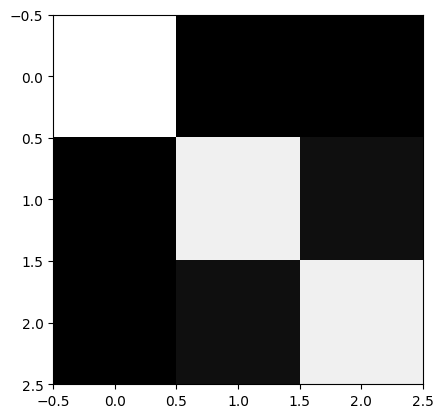

In [43]:
# 혼동 행렬을 이미지로 시각화하기 위해 pyplot을 불러온다.
import matplotlib.pyplot as plt

# 혼동 행렬 값을 회색조 이미지로 표시한다.
plt.imshow(conf_result, cmap='grey')